Fig. 5

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import csv
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    # 'xtick.major.pad': 3,
    # 'ytick.major.pad': 3,
})

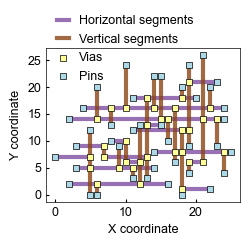

In [10]:
seg_num = 40
data_test = np.load(f'./data/Fig5/data_segment_{seg_num}.npz')
data_len = len(data_test)
segments_list = []
for i,id in enumerate(data_test):
    if i == (data_len-1):
        T_set = data_test[id]
    else:
        segments_list.append(data_test[id])

horizontal_segments = []
vertical_segments = []
intersection_map = {}

horizontal_counter = 0
vertical_counter = 0

for segments in segments_list:
    current_horizontal = []
    current_vertical = []

    for idx, (x1, y1, x2, y2) in enumerate(segments):
        if y1 == y2:
            current_horizontal.append((x1, y1, x2, y2, horizontal_counter))
            horizontal_counter += 1
        elif x1 == x2:
            current_vertical.append((x1, y1, x2, y2, vertical_counter))
            vertical_counter += 1

    horizontal_segments.extend(current_horizontal)
    vertical_segments.extend(current_vertical)

    current_intersection_map = {}
    
    for h_idx, (x1, y1, x2, y2, h_counter) in enumerate(current_horizontal):
        for v_idx, (x3, y3, x4, y4, v_counter) in enumerate(current_vertical):
            if y3 <= y1 <= y4 and x1 <= x3 <= x2:
                intersection = (x3, y1)

                if h_counter not in current_intersection_map:
                    current_intersection_map[h_counter] = set()
                
                current_intersection_map[h_counter].add(v_counter)

    intersection_map.update(current_intersection_map)

fig, ax = plt.subplots(figsize=(2.5, 2))

for h_idx, (x1, y1, x2, y2, h_counter) in enumerate(horizontal_segments):
    plt.plot([x1, x2], [y1, y2], '#7E4EA3', lw=3, label=f"Horizontal segments" if h_idx == 0 else "", alpha=0.8)

for v_idx, (x1, y1, x2, y2, v_counter) in enumerate(vertical_segments):
    plt.plot([x1, x1], [y1, y2], '#8B4513', lw=3, label=f"Vertical segments" if v_idx == 0 else "", alpha=0.8)

intersections = []
for h_counter, v_counters in intersection_map.items():
    for v_counter in v_counters:
        h_x1, h_y1, h_x2, h_y2, _ = horizontal_segments[h_counter]
        v_x1, v_y1, v_x2, v_y2, _ = vertical_segments[v_counter]
        
        intersection = (h_counter, v_counter, v_x1, h_y1)
        intersections.append(intersection)

if intersections:
    intersections = np.array(intersections)
    plt.scatter(intersections[:, 2], intersections[:, 3], color='#ffff99', marker="s", s=15, edgecolor="k", label="Vias", zorder=5, linewidths=0.5)

plt.scatter(T_set[:, 0], T_set[:, 1], color='lightblue', marker="s",s=15,edgecolor="k", label="Pins", zorder=5, linewidths=0.5)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(False)
fig.legend(frameon=False, bbox_to_anchor=(0.76, 1.10), ncol=1, handlelength=1.0)
plt.savefig("./plot/Fig5a.svg", bbox_inches='tight',dpi=800)
plt.show()

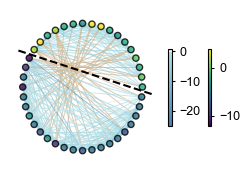

In [12]:
import networkx as nx
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

J = np.load("./data/Fig5/J.npy")
h = np.load("./data/Fig5/h.npy")
N = len(h)
G = nx.Graph()
for i in range(N):
    G.add_node(i, external_field=h[i])

for i in range(N):
    for j in range(i + 1, N):
        if J[i, j] != 0:
            G.add_edge(i, j, weight=J[i, j])

pos = nx.circular_layout(G)

fig = plt.figure(figsize=(3, 2))
ax = fig.add_subplot(111)

norm_node = mcolors.Normalize(vmin=min(h), vmax=max(h))
cmap_node = plt.get_cmap('viridis')
node_colors = [cmap_node(norm_node(value)) for value in h]

edges = G.edges(data=True)
weights = [data['weight'] for _, _, data in edges]
min_weight = min(weights)
max_weight = max(weights)

edges = G.edges(data=True)
weights = [data['weight'] for _, _, data in edges]
min_weight = min(weights)
max_weight = max(weights)

c1 = '#4682B4'
c2 = "#B0E0E6"
c3 = '#D2B48C'

if min_weight < 0 and max_weight > 0:
    midpoint = -min_weight / (max_weight - min_weight)
    red_point = midpoint * 0.99
    colors = [(0, c1), (red_point, c2), (midpoint, 'white'), (1, c3)]
    cmap_edge = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)
    norm_edge = mcolors.Normalize(vmin=min_weight, vmax=max_weight)
elif max_weight <= 0:
    cmap_edge = plt.get_cmap('Reds')
    norm_edge = mcolors.Normalize(vmin=min_weight, vmax=0)
else:
    cmap_edge = plt.get_cmap('Blues')
    norm_edge = mcolors.Normalize(vmin=0, vmax=max_weight)

edge_colors = [cmap_edge(norm_edge(w)) for w in weights]

nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.7, width = 0.7, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, edgecolors='k', node_size=20, alpha=0.8, ax=ax)

sm_node = cm.ScalarMappable(cmap=cmap_node, norm=norm_node)
sm_node.set_array(h)
cbar_node = plt.colorbar(sm_node, ax=ax, location='right', shrink=0.5)
cbar_node.ax.tick_params(direction='out')

sm_edge = cm.ScalarMappable(cmap=cmap_edge, norm=norm_edge)
sm_edge.set_array(weights)
cbar_edge = plt.colorbar(sm_edge, ax=ax, location='right', shrink=0.5)
cbar_edge.ax.tick_params(direction='out')

line = Line2D([-1.073, 1.161], [0.573, -0.113], color='k', linestyle='--')
ax.add_line(line)

plt.axis("off")
plt.savefig("./plot/Fig5c.svg", bbox_inches='tight',dpi=800)
plt.show()


17 23


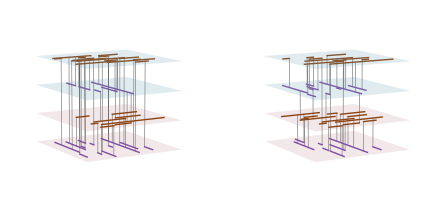

In [13]:
def layer_assign(N_h,var_num,s):
    layer = np.zeros((var_num,),dtype=int)
    for i in range(var_num):
        if i < N_h:
            layer[i] = 1 if s[i] == -1 else 3
        else:
            layer[i] = 2 if s[i] == -1 else 4
    return layer

def count_terminal_points(T_set, horizontal_segments, vertical_segments):
    N_h = len(horizontal_segments)
    Terminal_h = np.zeros(N_h, dtype=int)
    Terminal_v = np.zeros(len(vertical_segments), dtype=int)
    Terminals = np.zeros(len(T_set), dtype=int)
    
    for id, point in enumerate(T_set):
        x, y = point
        for i, (x1, y1, x2, y2, _) in enumerate(horizontal_segments):
            if y1 == y == y2 and x1 <= x <= x2:
                Terminal_h[i] += 1
                Terminals[id] = i

    for id, point in enumerate(T_set):
        x, y = point
        for i, (x1, y1, x2, y2, _) in enumerate(vertical_segments):
            if x1 == x == x2 and y1 <= y <= y2:
                Terminal_v[i] += 1
                Terminals[id] = N_h + i
    
    return Terminal_h, Terminal_v, Terminals

seg_num = 40
data_test = np.load(f'./data/Fig5/data_segment_{seg_num}.npz')
data_len = len(data_test)
segments_list = []
for i,id in enumerate(data_test):
    if i == (data_len-1):
        T_set = data_test[id]
    else:
        segments_list.append(data_test[id])

horizontal_segments = []
vertical_segments = []
intersection_map = {}

horizontal_counter = 0
vertical_counter = 0

for segments in segments_list:
    current_horizontal = []
    current_vertical = []

    for idx, (x1, y1, x2, y2) in enumerate(segments):
        if y1 == y2:
            current_horizontal.append((x1, y1, x2, y2, horizontal_counter))
            horizontal_counter += 1
        elif x1 == x2:
            current_vertical.append((x1, y1, x2, y2, vertical_counter))
            vertical_counter += 1

    horizontal_segments.extend(current_horizontal)
    vertical_segments.extend(current_vertical)

    current_intersection_map = {}
    
    for h_idx, (x1, y1, x2, y2, h_counter) in enumerate(current_horizontal):
        for v_idx, (x3, y3, x4, y4, v_counter) in enumerate(current_vertical):
            if y3 <= y1 <= y4 and x1 <= x3 <= x2:
                intersection = (x3, y1)

                if h_counter not in current_intersection_map:
                    current_intersection_map[h_counter] = set()
                
                current_intersection_map[h_counter].add(v_counter)

    intersection_map.update(current_intersection_map)

intersections = []
for h_counter, v_counters in intersection_map.items():
    for v_counter in v_counters:
        h_x1, h_y1, h_x2, h_y2, _ = horizontal_segments[h_counter]
        v_x1, v_y1, v_x2, v_y2, _ = vertical_segments[v_counter]
        
        intersection = (h_counter, v_counter, v_x1, h_y1)
        intersections.append(intersection)

if intersections:
    intersections = np.array(intersections)

_, _, T_pos = count_terminal_points(T_set, horizontal_segments, vertical_segments)
N_h = len(horizontal_segments)
N_v = len(vertical_segments)
# print(N_h,N_v)
N_t = len(T_set)
var_num = N_h + N_v
s_process = np.load(f"./data/Fig5/s_process_1.npy")

fig = plt.figure(figsize=(5.4,2.8))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

np.random.seed(42)
s_ini = np.random.choice([-1, 1], size=(var_num,))
s_last = s_process[-1,:]
layer_ini = layer_assign(N_h,var_num,s_ini)
layer_last = layer_assign(N_h,var_num,s_last)
#plot Horizontal segments
for h_idx, (x1, y1, x2, y2, _) in enumerate(horizontal_segments):
    ax1.plot([x1, x2], [y1, y2], [layer_ini[h_idx], layer_ini[h_idx]], color = '#7E4EA3', lw = 1, zorder=4)

#plot Vertical segments
for v_idx, (x1, y1, x2, y2, _) in enumerate(vertical_segments):
    ax1.plot([x1, x1], [y1, y2], [layer_ini[v_idx+N_h], layer_ini[v_idx+N_h]], color = '#8B4513', lw = 1, zorder=4)

#plot vias caused by connectivity
for h_counter, v_counter, x, y in intersections:
    ax1.plot([x, x], [y, y], [layer_ini[h_counter], layer_ini[v_counter+N_h]], 'k-', zorder=2, lw=0.5, alpha=0.5)

#plot Horizontal segments
for h_idx, (x1, y1, x2, y2, _) in enumerate(horizontal_segments):
    ax2.plot([x1, x2], [y1, y2], [layer_last[h_idx], layer_last[h_idx]], color = '#7E4EA3', lw = 1, zorder=4, label="Horizontal segment" if h_idx == 0 else "")

#plot Vertical segments
for v_idx, (x1, y1, x2, y2, _) in enumerate(vertical_segments):
    ax2.plot([x1, x1], [y1, y2], [layer_last[v_idx+N_h], layer_last[v_idx+N_h]], color = '#8B4513', lw = 1, zorder=4, label="Vertical segment" if v_idx == 0 else "")

#plot vias caused by connectivity
for i_idx, (h_counter, v_counter, x, y) in enumerate(intersections):
    ax2.plot([x, x], [y, y], [layer_last[h_counter], layer_last[v_counter+N_h]], 'k-', zorder=2, lw=0.5, alpha=0.5, label="Via" if i_idx == 0 else "")

x_min, x_max = ax1.get_xlim()
y_min, y_max = ax1.get_ylim()

zz_values = [1, 2, 3, 4]
colors = [(255/255, 182/255, 193/255), (255/255, 182/255, 193/255), (135/255, 206/255, 235/255), (135/255, 206/255, 235/255)]  # 对应的颜色，红色和蓝色交替

for zz, color in zip(zz_values, colors):
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(y_min, y_max, 10))
    zz_grid = np.full_like(xx, zz)

    ax1.plot_surface(xx, yy, zz_grid, color=color, alpha=0.2)
    ax2.plot_surface(xx, yy, zz_grid, color=color, alpha=0.2)

ax1.set_axis_off()
ax2.set_axis_off()
ax1.view_init(elev=10, azim=-30)
ax2.view_init(elev=10, azim=-30)

# fig.text(0.31, 0.23, 'Random solution', ha='center', va='center')
# fig.text(0.74, 0.23, 'Optimal solution', ha='center', va='center')
plt.savefig(f"./plot/Fig5e.svg", bbox_inches='tight',dpi=800)
plt.show()

number of variables: 40


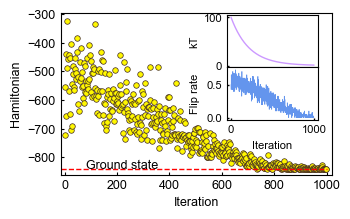

In [27]:
def calculate_horizontal_distance(h1, h2):
    x1, y1, x2, y2, _ = h1
    x3, y3, x4, y4, _ = h2

    overlap_length = max(0, min(x2, x4) - max(x1, x3))
    if overlap_length == 0:
        return 0

    vertical_distance = abs(y1 - y3)

    if vertical_distance == 0:
        return 0
    else:
        return overlap_length / vertical_distance

def calculate_vertical_distance(v1, v2):
    x1, y1, x2, y2, _ = v1
    x3, y3, x4, y4, _ = v2

    overlap_length = max(0, min(y2, y4) - max(y1, y3))
    if overlap_length == 0:
        return 0

    horizontal_distance = abs(x1 - x3)

    if horizontal_distance == 0:
        return 0
    else:
        return overlap_length / horizontal_distance

def compute_distances(horizontal_segments, vertical_segments):
    horizontal_distances = np.zeros((len(horizontal_segments), len(horizontal_segments)))
    for i, h1 in enumerate(horizontal_segments):
        for j, h2 in enumerate(horizontal_segments):
            if i < j:
                dist = calculate_horizontal_distance(h1, h2)
                horizontal_distances[i][j] = dist
                horizontal_distances[j][i] = dist

    vertical_distances = np.zeros((len(vertical_segments), len(vertical_segments)))
    for i, v1 in enumerate(vertical_segments):
        for j, v2 in enumerate(vertical_segments):
            if i < j:
                dist = calculate_vertical_distance(v1, v2)
                vertical_distances[i][j] = dist
                vertical_distances[j][i] = dist

    return horizontal_distances, vertical_distances

def build_connectivity(horizontal_segments, vertical_segments, intersection_map):
    connectivity = np.zeros((len(horizontal_segments), len(vertical_segments)), dtype=int)
    
    for h_idx, v_indices in intersection_map.items():
        for v_idx in v_indices:
            connectivity[h_idx][v_idx] = 1
    
    return connectivity

def count_terminal_points(T_set, horizontal_segments, vertical_segments):
    N_h = len(horizontal_segments)
    Terminal_h = np.zeros(N_h, dtype=int)
    Terminal_v = np.zeros(len(vertical_segments), dtype=int)
    Terminals = np.zeros(len(T_set), dtype=int)
    
    for id, point in enumerate(T_set):
        x, y = point
        for i, (x1, y1, x2, y2, _) in enumerate(horizontal_segments):
            if y1 == y == y2 and x1 <= x <= x2:
                Terminal_h[i] += 1
                Terminals[id] = i

    for id, point in enumerate(T_set):
        x, y = point
        for i, (x1, y1, x2, y2, _) in enumerate(vertical_segments):
            if x1 == x == x2 and y1 <= y <= y2:
                Terminal_v[i] += 1
                Terminals[id] = N_h + i
    
    return Terminal_h, Terminal_v, Terminals

def calculate_Hamiltonian(s, D, C, T, N_h, N_v):
    var_num = N_h + N_v
    H_D = 0
    for i in range(N_h-1):
        for j in range(i+1,N_h):
            H_D += 0.5 * D[i,j] * (s[i]*s[j] - 1)
    for m in range(N_h,var_num-1):
        for n in range(m+1,var_num):
            H_D += 0.5 * D[m,n] * (s[m]*s[n] - 1)

    H_V = 0
    x = (s + 1) / 2
    for i in range(N_h):
        for m in range(N_h,var_num):
            H_V += C[i,m] * (3*(x[m]-x[i]*x[m])+x[i]+(1-x[i])*(1-x[m]))
    H_V_C = H_V
    for i in range(N_h):
        H_V += T[i] * (s[i] + 2)
    for m in range(N_h,var_num):
        H_V += T[m] * (s[m] + 3)
    
    return H_D,H_V

seg_num = 40
data_test = np.load(f'./data/Fig5/data_segment_{seg_num}.npz')
data_len = len(data_test)
segments_list = []
for i,id in enumerate(data_test):
    if i == (data_len-1):
        T_set = data_test[id]
    else:
        segments_list.append(data_test[id])

horizontal_segments = []
vertical_segments = []
intersection_map = {}

horizontal_counter = 0
vertical_counter = 0

for segments in segments_list:
    current_horizontal = []
    current_vertical = []

    for idx, (x1, y1, x2, y2) in enumerate(segments):
        if y1 == y2:
            current_horizontal.append((x1, y1, x2, y2, horizontal_counter))
            horizontal_counter += 1
        elif x1 == x2:
            current_vertical.append((x1, y1, x2, y2, vertical_counter))
            vertical_counter += 1

    horizontal_segments.extend(current_horizontal)
    vertical_segments.extend(current_vertical)
    current_intersection_map = {}
    
    for h_idx, (x1, y1, x2, y2, h_counter) in enumerate(current_horizontal):
        for v_idx, (x3, y3, x4, y4, v_counter) in enumerate(current_vertical):
            if y3 <= y1 <= y4 and x1 <= x3 <= x2:
                intersection = (x3, y1)

                if h_counter not in current_intersection_map:
                    current_intersection_map[h_counter] = set()
                
                current_intersection_map[h_counter].add(v_counter)

    intersection_map.update(current_intersection_map)

intersections = []
for h_counter, v_counters in intersection_map.items():
    for v_counter in v_counters:
        h_x1, h_y1, h_x2, h_y2, _ = horizontal_segments[h_counter]
        v_x1, v_y1, v_x2, v_y2, _ = vertical_segments[v_counter]
        
        intersection = (h_counter, v_counter, v_x1, h_y1)
        intersections.append(intersection)

if intersections:
    intersections = np.array(intersections)

weights_h, weights_v = compute_distances(horizontal_segments, vertical_segments)
connectivity = build_connectivity(horizontal_segments, vertical_segments, intersection_map)
Terminal_h, Terminal_v, T_pos = count_terminal_points(T_set, horizontal_segments, vertical_segments)

N_h = len(horizontal_segments)
N_v = len(vertical_segments)
var_num = N_h + N_v
print(f"number of variables: {var_num}")
D = np.block([[weights_h, np.zeros((N_h, N_v))], [np.zeros((N_v, N_h)), weights_v]])
C = np.block([[np.zeros((N_h, N_h)), connectivity]])
T = np.append(Terminal_h,Terminal_v)

lambda_D = 10
lambda_V = 4
T_max = 100
s_process = np.load(f"./data/Fig5/s_process_2.npy")
T_min = 1
Iteration = s_process.shape[0]
decay = pow(T_min/T_max,1.0/Iteration)
H = np.zeros((Iteration,))
for i in range(Iteration):
    H_D,H_V = calculate_Hamiltonian(s_process[i,:], D, C, T, N_h, N_v)
    H[i] = lambda_D * H_D + lambda_V * H_V

ground = np.min(H)
# print(ground)
Iter_plot = np.arange(1,Iteration+1)
T_plot = T_max * (decay ** Iter_plot)

flip_rate = np.zeros((Iteration,))
for i in range(Iteration-1):
    flip_num = 0
    for m in range(var_num):
        if s_process[i,m] != s_process[i+1,m]:
            flip_num += 1
    flip_rate[i] = flip_num / var_num

fig, ax = plt.subplots(figsize=(3.5,2.1))
interval = 2
Iter_plot_1 = Iter_plot[::interval]
H_plot = H[::interval]
linecolor = '#3E2723'
ax.plot(Iter_plot_1 , H_plot,lw=0.5,linestyle='none', color=linecolor, marker="o", markersize=4, markerfacecolor='#FFF700', markeredgecolor=linecolor,markeredgewidth=0.5)
ax.plot([-15, Iter_plot[-1]], [ground, ground], 'r--',lw=1)
ax.text(80, ground+2, 'Ground state', color='k')
ax.set_xlim(-15, Iter_plot[-1]+20)
ax.set_ylim(min(H) - 20, max(H) + 30)
ax.set_xlabel("Iteration")
ax.set_ylabel("Hamiltonian")

ax_inset_1 = fig.add_axes([0.6, 0.62, 0.26, 0.25])
ax_inset_1.plot(Iter_plot, T_plot, color='#CC99FF', alpha=1, lw=1)

ax_inset_2 = fig.add_axes([0.6, 0.37, 0.26, 0.25])
ax_inset_2.plot(Iter_plot, flip_rate, color='cornflowerblue', alpha=1, lw=0.5)

ax_inset_1.set_ylabel('kT', fontsize=8)
ax_inset_1.tick_params(labelsize=8, direction="in", width=1, length=1.5)
ax_inset_1.set_xticks([])
ax_inset_1.yaxis.set_label_coords(x=-0.3, y=0.5)

ax_inset_2.set_xlabel('Iteration', fontsize=8)
ax_inset_2.set_ylabel('Flip rate', fontsize=8)
ax_inset_2.tick_params(labelsize=8, direction="in", width=1, length=1.5)
ax_inset_2.yaxis.set_label_coords(x=-0.3, y=0.5)
plt.savefig(f"./plot/Fig5d.svg", bbox_inches='tight',dpi=800)
plt.show()


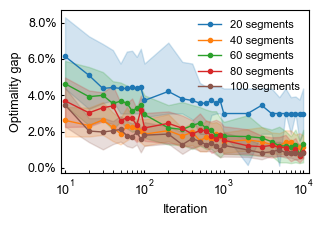

In [24]:
from matplotlib.ticker import PercentFormatter

def calculate_gap(A,size):
    M, N = A.shape
    G = np.zeros_like(A)
    
    for i in range(M):
        min_val = np.min(A[i,:])
        for j in range(N):
            G[i,j] = abs((A[i,j] - min_val) / min_val)
    
    return G

size_list = [20,40,60,80,100]
test_iters = [10,20,30,40,50,60,70,80,90,100,200,300,400,500,600,700,800,900,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]

color_list = [
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c',
    '#d62728',
    '#8c564b',
    '#E0E0E0'
]

min_H_list = np.array([-1076.4789377289376,-2819.521634411341,-3780,-4600,-5400],dtype=np.float32)
fig,ax = plt.subplots(figsize=(3.2,2.12))
for j in range(len(size_list)):
    H_vary_with_iters = np.load(f"./data/Fig5/H_last_vs_problem_size/last_H_vs_iters_{size_list[j]}.npy")
    opt_gap = calculate_gap(H_vary_with_iters,size_list[j])
    gap_mean = np.mean(opt_gap, axis=1)
    gap_median = np.median(opt_gap, axis=1)
    q1 = np.percentile(opt_gap, 25, axis=1)
    q3 = np.percentile(opt_gap, 75, axis=1)
    gap_std = np.std(opt_gap, axis=1)
    plt.plot(test_iters,gap_median,marker='o', markersize=3, color=color_list[j],lw=1,label=f"{size_list[j]} segments")
    plt.fill_between(test_iters, 
                 q1, 
                 q3, 
                 alpha=0.2, color=color_list[j])

plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))
ax.set_xlabel("Iteration")
ax.set_ylabel("Optimality gap")
ax.set_xscale("log")
ax.set_xlim(9,12000)
plt.legend(loc="upper right", frameon=False, fontsize=9)
plt.savefig("./plot/Fig5f.svg", bbox_inches='tight',dpi=800)
plt.show()